# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 11: Árboles de Decisión y Random Forest.**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns
import math
import sys
import os
import joblib
import warnings
from scipy.stats import randint as sp_randint

from sklearn.tree import (DecisionTreeClassifier, plot_tree, export_text)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_score, learning_curve)
from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")

np.random.seed(42)

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s10")
src_path = os.path.join(absolute_path, "src", "s11")
model_path = os.path.join(absolute_path, "models", "s11")
figure_path = os.path.join(absolute_path, "figuras", "s11")
sys.path.insert(0, src_path)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from evaluation import Evaluation

## 🎯 **Objetivos de la sesión**

El objetivo de esta sesión es poder entender el funcionamiento de los modelos de árboles:

1. **Comprender** la lógica matemática detrás de los Árboles de Decisión (CART) y su aplicación en credit scoring.
2. **Entender** por qué Random Forest mejora al árbol individual y cuál es el rol del bagging y la aleatoriedad.
3. **Implementar** ambos modelos en Python con scikit-learn sobre datos crediticios reales.
4. **Optimizar** hiperparámetros mediante Validación Cruzada Estratificada y RandomizedSearchCV.
5. **Evaluar** el desempeño usando las métricas estándar del curso (AUC-ROC, Gini, KS).
6. **Interpretar** la importancia de variables y conectar los resultados con el negocio crediticio.
7. **Decidir** cuándo usar cada modelo en un entorno bancario real.


# 🗂️ **1. Dataset sesión 10**

📑 **Diccionario de Datos: Crédito Semi-Sintético**
| N° | Variable | Descripción | Categoría |
| :---: | :--- | :--- | :---: |
| **1** | `DEFAULT` | **Variable Objetivo (Target)**: {0: al día, 1: incumplimiento en 12 meses}. | 🎯 |
| **2** | `ID_CLIENTE` | Identificador único alfanumérico del cliente (ej. CLI000001). | 🆔 |
| **3** | `EDAD` | Edad del cliente en años (rango de 18 a 75). | 👤 |
| **4** | `GENERO` | Género del solicitante: **M** (Masculino) o **F** (Femenino). | 👫 |
| **5** | `ESTADO_CIVIL` | Situación civil: Soltero, Casado, Divorciado o Viudo. | 💍 |
| **6** | `NIVEL_EDUCATIVO` | Máximo nivel alcanzado: Secundaria, Técnico, Universitario o Postgrado. | 🎓 |
| **7** | `NUM_DEPENDIENTES` | Número de personas que dependen económicamente del titular (0 a 4). | 👨‍👩‍👧‍👦 |
| **8** | `TIPO_EMPLEO` | Situación laboral: Dependiente, Independiente, Empresario, Jubilado o Sin empleo. | 💼 |
| **9** | `INGRESO_MENSUAL` | Ingresos mensuales netos (incluye ~8% de valores nulos). | 💵 |
| **10** | `ANTIGUEDAD_LABORAL` | Años de experiencia en el empleo actual (incluye ~5% de valores nulos). | ⏳ |
| **11** | `TIPO_CREDITO` | Categoría del préstamo: Consumo, Hipotecario, Vehicular o Empresarial. | 🏷️ |
| **12** | `MONTO_CREDITO` | Monto total del capital solicitado en el préstamo. | 💰 |
| **13** | `PLAZO_MESES` | Tiempo pactado para la devolución del crédito (12 a 120 meses). | 📅 |
| **14** | `TASA_INTERES` | Tasa de interés anual aplicada al producto crediticio. | 📈 |
| **15** | `NUM_CREDITOS_PREVIOS` | Cantidad de créditos registrados anteriormente en el sistema. | 📂 |
| **16** | `DIAS_MORA_MAX` | Máximo de días de atraso histórico registrado (incluye ~6% de valores nulos). | ⚠️ |
| **17** | `RATIO_UTILIZACION` | Porcentaje de uso de líneas de crédito (0 a 1). | 💳 |
| **18** | `TIPO_VIVIENDA` | Régimen de vivienda: Propia, Arrendada, Familiar o Hipotecada. | 🏠 |
| **19** | `RATIO_LTV` | *Loan to Value*: Porcentaje del valor del bien financiado (solo Hipotecarios). | 🏠📉 |

In [2]:
X_train = pd.read_csv(os.path.join(data_path, 'X_train_proc.csv'))
X_test  = pd.read_csv(os.path.join(data_path, 'X_test_proc.csv'))
X_val   = pd.read_csv(os.path.join(data_path, 'X_val_proc.csv'))
y_train = pd.read_csv(os.path.join(data_path, 'y_train.csv'))
y_test  = pd.read_csv(os.path.join(data_path, 'y_test.csv'))
y_val   = pd.read_csv(os.path.join(data_path, 'y_val.csv'))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_val shape: {X_val.shape}")

print(f"y_train defaul rate: {y_train['DEFAULT'].mean()*100:.2f}")
print(f"y_test defaul rate: {y_test['DEFAULT'].mean()*100:.2f}")
print(f"y_val defaul rate: {y_val['DEFAULT'].mean()*100:.2f}")

print(f"X_train columns: {X_train.columns.tolist()}")

X_train shape: (17341, 24)
X_test shape: (7875, 24)
X_val shape: (4784, 24)
y_train defaul rate: 22.38
y_test defaul rate: 22.60
y_val defaul rate: 22.49
X_train columns: ['EDAD', 'NIVEL_EDUCATIVO', 'NUM_DEPENDIENTES', 'TIPO_EMPLEO', 'ANTIGUEDAD_LABORAL', 'TIPO_CREDITO', 'PLAZO_MESES', 'TASA_INTERES', 'NUM_CREDITOS_PREVIOS', 'DIAS_MORA_MAX', 'RATIO_UTILIZACION', 'TIPO_VIVIENDA', 'RATIO_LTV', 'IND_INGRESO_MISSING', 'IND_HISTORIAL_MISSING', 'CASADO', 'HOMBRE', 'CUOTA_ESTIMADA', 'RATIO_ENDEUDAMIENTO', 'SEGMENTO_RIESGO', 'INTERACCION_EDAD_MORA', 'LOG_INGRESO_MENSUAL', 'LOG_MONTO_CREDITO', 'MES_STR']


In [3]:
X_train.set_index("MES_STR", inplace=True)
X_test.set_index("MES_STR", inplace=True)
X_val.set_index("MES_STR", inplace=True)

In [4]:
X_train.head()

,EDAD,NIVEL_EDUCATIVO,NUM_DEPENDIENTES,TIPO_EMPLEO,ANTIGUEDAD_LABORAL,TIPO_CREDITO,PLAZO_MESES,TASA_INTERES,NUM_CREDITOS_PREVIOS,DIAS_MORA_MAX,RATIO_UTILIZACION,TIPO_VIVIENDA,RATIO_LTV,IND_INGRESO_MISSING,IND_HISTORIAL_MISSING,CASADO,HOMBRE,CUOTA_ESTIMADA,RATIO_ENDEUDAMIENTO,SEGMENTO_RIESGO,INTERACCION_EDAD_MORA,LOG_INGRESO_MENSUAL,LOG_MONTO_CREDITO
MES_STR,,,,,,,,,,,,,,,,,,,,,,,
2025-01,0.970257,0,0.577149,3,0.436922,3,1.772926,-0.016108,-0.008424,0.092122,-0.563435,3,-0.635404,1,0,0,0.957923,-0.577534,-0.574146,0,-0.090358,0.492354,-0.713604
2025-01,-1.248747,2,-0.282157,2,-0.787466,0,1.772926,0.144035,-0.585839,-0.608223,-0.800695,0,1.258868,0,1,1,0.957923,-0.583324,-0.575171,0,-0.569146,0.430020,-0.796076
2025-01,1.432550,1,-1.141463,2,-0.964486,0,0.215227,0.607606,1.146406,-0.608223,-0.030888,2,1.787022,0,0,0,-1.043926,-0.443822,-0.492999,0,-0.569146,0.444472,-0.298246
2025-01,-0.416621,2,-1.141463,3,0.790962,0,-0.304006,-1.180935,-0.585839,1.492811,0.401081,0,1.199857,0,0,1,0.957923,-0.110344,0.241128,3,1.449525,-1.050781,0.528165
2025-01,1.525008,2,-1.141463,1,0.186144,3,-0.823239,-0.179622,0.568991,-0.608223,-1.146271,3,-0.635404,0,0,1,-1.043926,-0.182003,0.007942,2,-0.569146,-0.773464,-0.016792


# 🎯 **1 · Contexto y motivación**

## **1.1 ¿Qué hemos construido hasta ahora y cuál es su limitación?**
En la Sesión 5 construimos un modelo de **Regresión Logística** con variables transformadas por WOE. Este modelo es:
- Interpretable: los coeficientes tienen signo y magnitud claros.
- Estable: bien aceptado por reguladores bajo Basilea y IFRS 9.
- **Lineal**: asume que la relación entre cada variable (en escala WOE) y el log-odds de incumplimiento es **constante**.

El problema es que la realidad crediticia raramente es lineal. 

## **1.2 La intuición del árbol: reglas de negocio naturales**

Un árbol de decisión modela exactamente cómo un analista de riesgo senior piensa:

```
¿Atraso > 30 días?
    ├── SÍ → ¿Ratio deuda/ingreso > 0.5?
    │         ├── SÍ → ALTO RIESGO (mora: 42%)
    │         └── NO → RIESGO MEDIO (mora: 18%)
    └── NO → ¿Antigüedad laboral < 1 año?
              ├── SÍ → RIESGO MEDIO (mora: 15%)
              └── NO → BAJO RIESGO (mora: 4%)
```

Esto es exactamente un árbol. Las **hojas** son segmentos homogéneos del portafolio, cada uno con su propia tasa de mora estimada.

## **1.3 ¿Cuándo los árboles ganan a la regresión logística?**

| Situación | ¿Conviene árbol/RF? | Por qué |
|-----------|--------------------|------------------------------------|
| Variables con interacciones no lineales | ✅ Sí | El árbol las captura automáticamente |
| Variables numéricas sin transformar (sin WOE) | ✅ Sí | No necesitan binning previo |
| Portafolios segmentados (retail + pyme + hipotecas) | ✅ Sí | Cada rama puede capturar un segmento |
| Outliers extremos | ⚠️ Depende | Los árboles son robustos; RF más aún |
| Modelo para comité regulatorio | ⛔ Precaución | Requiere explicabilidad adicional (SHAP, Sesión 14) |
| Dataset pequeño (<1,000 obs) | ⛔ No | RF necesita masa crítica para generalizar |

# 🌿 **2 · Decision Tree**

## **2.1 Fundamento matemático: entropía e information gain**

El algoritmo Decision Tree construye el árbol eligiendo en cada nodo la pregunta:

> **"¿Qué corte genera la mayor ganancia de información?"**

La **entropía de Shannon** mide el desorden (incertidumbre) en un nodo:

$$H(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

Donde $p_k$ es la proporción de la clase $k$ en el nodo $t$.

- **Nodo puro** (todos incumplen o ninguno): $H = 0$ bits ✅  
- **Nodo máxima incertidumbre** (50% cada clase): $H = 1$ bit ❌

El árbol elige el corte que maximiza el **Information Gain**:

$$IG = H(\text{padre}) - \left(\frac{n_L}{n} H(t_L) + \frac{n_R}{n} H(t_R)\right)$$

## **2.2 Ejemplo manual con datos crediticios**

Nodo raíz: **200 clientes → 160 buenos / 40 malos** (tasa mora: 20%)

Evaluamos dos cortes sobre **"Atraso máximo en días"**:

| Corte | Rama izquierda | Rama derecha |
|-------|---------------|--------------|
| **A** ≤ 15 días | 130 buenos / 10 malos (140 clientes) | 30 buenos / 30 malos (60 clientes) |
| **B** ≤ 30 días | 150 buenos / 20 malos (170 clientes) | 10 buenos / 20 malos (30 clientes) |

¿Cuál genera mayor Information Gain?

In [5]:
def entropia(buenos, malos):
    """Calcula entropía de Shannon dado conteo de buenos y malos."""
    n = buenos + malos
    if n == 0:
        return 0
    p_bueno = buenos / n
    p_malo  = malos / n
    # Evitamos log(0): si p=0, ese término aporta 0
    h = 0
    if p_bueno > 0:
        h -= p_bueno * math.log2(p_bueno)
    if p_malo > 0:
        h -= p_malo  * math.log2(p_malo)
    return h

def information_gain(padre_b, padre_m, izq_b, izq_m, der_b, der_m):
    """Calcula el Information Gain de un corte."""
    n_padre = padre_b + padre_m
    n_izq   = izq_b + izq_m
    n_der   = der_b + der_m

    H_padre = entropia(padre_b, padre_m)
    H_izq   = entropia(izq_b, izq_m)
    H_der   = entropia(der_b, der_m)

    H_corte = (n_izq / n_padre) * H_izq + (n_der / n_padre) * H_der
    ig      = H_padre - H_corte
    return H_padre, H_izq, H_der, H_corte, ig

# ── Nodo padre ────────────────────────────────────────────────
print("=" * 60)
print("NODO PADRE: 160 buenos | 40 malos | Tasa mora: 20.0%")
print(f"Entropía padre: {entropia(160, 40):.4f} bits")
print("=" * 60)

# ── Corte A: ≤15 días → 130B/10M | >15 días → 30B/30M ────────
Hp, Hi, Hd, Hc, ig1 = information_gain(160, 40, 130, 10, 30, 30)
print(f"\nCorte A (≤ 15 días vs > 15 días):")
print(f"  Izquierda (≤15):  130 buenos, 10 malos  →  mora {10/140:.1%}  | H = {Hi:.4f} bits")
print(f"  Derecha   (>15):   30 buenos, 30 malos  →  mora {30/60:.1%}  | H = {Hd:.4f} bits")
print(f"  Entropía ponderada del corte: {Hc:.4f} bits")
print(f"  Information Gain: {ig1:.4f} bits")

# ── Corte B: ≤30 días → 150B/20M | >30 días → 10B/20M ────────
Hp, Hi, Hd, Hc, ig2 = information_gain(160, 40, 150, 20, 10, 20)
print(f"\nCorte B (≤ 30 días vs > 30 días):")
print(f"  Izquierda (≤30):  150 buenos, 20 malos  →  mora {20/170:.1%}  | H = {Hi:.4f} bits")
print(f"  Derecha   (>30):   10 buenos, 20 malos  →  mora {20/30:.1%}  | H = {Hd:.4f} bits")
print(f"  Entropía ponderada del corte: {Hc:.4f} bits")
print(f"  Information Gain: {ig2:.4f} bits")

print(f"\n🏆 El algoritmo elegiría: {'Corte A' if ig1 > ig2 else 'Corte B'}")
print("   Mayor Information Gain → mayor reducción de incertidumbre → mejor corte")

NODO PADRE: 160 buenos | 40 malos | Tasa mora: 20.0%
Entropía padre: 0.7219 bits

Corte A (≤ 15 días vs > 15 días):
  Izquierda (≤15):  130 buenos, 10 malos  →  mora 7.1%  | H = 0.3712 bits
  Derecha   (>15):   30 buenos, 30 malos  →  mora 50.0%  | H = 1.0000 bits
  Entropía ponderada del corte: 0.5599 bits
  Information Gain: 0.1621 bits

Corte B (≤ 30 días vs > 30 días):
  Izquierda (≤30):  150 buenos, 20 malos  →  mora 11.8%  | H = 0.5226 bits
  Derecha   (>30):   10 buenos, 20 malos  →  mora 66.7%  | H = 0.9183 bits
  Entropía ponderada del corte: 0.5819 bits
  Information Gain: 0.1400 bits

🏆 El algoritmo elegiría: Corte A
   Mayor Information Gain → mayor reducción de incertidumbre → mejor corte


## **2.2 Fundamento matemático: el criterio de Gini**

El algoritmo CART (Classification and Regression Trees) construye el árbol haciendo en cada nodo la pregunta:

> **"¿Qué corte divide los datos en dos grupos más puros?"**

La **impureza de Gini** mide cuán mezcladas están las clases en un nodo:

$$G(t) = 1 - \sum_{k=1}^{K} p_k^2$$

Donde $p_k$ es la proporción de observaciones de clase $k$ en el nodo $t$.

- **Nodo puro** (todos incumplen o ninguno): $G = 0$ ✅
- **Nodo máxima impureza** (50% cada clase): $G = 0.5$ ❌

El árbol elige el corte que maximiza la **reducción de Gini** (Gini Gain):

$$\Delta G = G(\text{padre}) - \left(\frac{n_L}{n} G(t_L) + \frac{n_R}{n} G(t_R)\right)$$

In [6]:
# ── Árbol SIN restricciones: demostración de overfitting ─────────────────────
dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train, y_train)

auc_train_of = roc_auc_score(y_train, dt_overfit.predict_proba(X_train)[:, 1])
auc_test_of  = roc_auc_score(y_test,  dt_overfit.predict_proba(X_test)[:, 1])
auc_val_of   = roc_auc_score(y_val,   dt_overfit.predict_proba(X_val)[:, 1])

print("=" * 55)
print("ÁRBOL SIN RESTRICCIONES (overfitting intencional)")
print("=" * 55)
print(f"  Profundidad máxima alcanzada : {dt_overfit.get_depth()}")
print(f"  Número de hojas              : {dt_overfit.get_n_leaves():,}")
print(f"  AUC – Train                  : {auc_train_of:.4f}  ← optimista")
print(f"  AUC – Test                   : {auc_test_of:.4f}")
print(f"  AUC – Validación             : {auc_val_of:.4f}")
print(f"  Brecha Train–Val             : {auc_train_of - auc_val_of:.4f}  ← overfitting")
print("=" * 55)
print("\n Conclusión: un árbol sin parámetros, regularizaciones, cross validation, etc., falla en generalizar.")

ÁRBOL SIN RESTRICCIONES (overfitting intencional)
  Profundidad máxima alcanzada : 30
  Número de hojas              : 2,687
  AUC – Train                  : 1.0000  ← optimista
  AUC – Test                   : 0.5887
  AUC – Validación             : 0.5965
  Brecha Train–Val             : 0.4035  ← overfitting

 Conclusión: un árbol sin parámetros, regularizaciones, cross validation, etc., falla en generalizar.


## **2.4 Hiperparámetros clave: qué son, qué controlan y cómo elegirlos**

Estos son los parámetros más importantes del `DecisionTreeClassifier` en un contexto de **credit scoring**:

In [7]:
# ── Tabla explicativa de hiperparámetros ─────────────────────────────────────
params_dt = pd.DataFrame({
    'Parámetro': [
        'max_depth',
        'min_samples_leaf',
        'min_samples_split',
        'max_features',
        'criterion',
        'class_weight',
        'ccp_alpha'
    ],
    'Qué controla': [
        'Profundidad máxima del árbol',
        'Mínimo de obs. en cada hoja final',
        'Mínimo de obs. para dividir un nodo',
        'Nº de features consideradas en cada split',
        'Función de impureza para evaluar cortes',
        'Peso de la clase positiva (morosos)',
        'Parámetro de poda (cost-complexity)'
    ],
    'Valor bajo → ': [
        'Árbol poco profundo (underfitting)',
        'Hojas con pocas obs. (overfitting)',
        'Permite splits con poca data (overfitting)',
        'Menos variables → árboles más débiles',
        '—',
        'Ignora desbalance de clases',
        'Sin poda (árbol completo)'
    ],
    'Valor alto → ': [
        'Árbol profundo (overfitting)',
        'Hojas más robustas (generaliza mejor)',
        'Requiere más obs. para dividir (regulariza)',
        'Más variables → puede overfit en features raras',
        '—',
        'Penaliza más los falsos negativos',
        'Poda agresiva (underfitting posible)'
    ],
    'Rango recomendado (scoring)': [
        '4 – 10',
        '50 – 500 según tamaño del portafolio',
        '2 × min_samples_leaf',
        'None (usa todas) en árbol individual',
        "'gini' (default) o 'entropy'",
        "'balanced' si mora < 10%",
        'Explorar 0.0001 – 0.01'
    ]
})

with pd.option_context('display.max_colwidth', 60):
    display(params_dt)

,Parámetro,Qué controla,Valor bajo →,Valor alto →,Rango recomendado (scoring)
0,max_depth,Profundidad máxima del árbol,Árbol poco profundo (underfitting),Árbol profundo (overfitting),4 – 10
1,min_samples_leaf,Mínimo de obs. en cada hoja final,Hojas con pocas obs. (overfitting),Hojas más robustas (generaliza mejor),50 – 500 según tamaño del portafolio
2,min_samples_split,Mínimo de obs. para dividir un nodo,Permite splits con poca data (overfitting),Requiere más obs. para dividir (regulariza),2 × min_samples_leaf
3,max_features,Nº de features consideradas en cada split,Menos variables → árboles más débiles,Más variables → puede overfit en features raras,None (usa todas) en árbol individual
4,criterion,Función de impureza para evaluar cortes,—,—,'gini' (default) o 'entropy'
5,class_weight,Peso de la clase positiva (morosos),Ignora desbalance de clases,Penaliza más los falsos negativos,'balanced' si mora < 10%
6,ccp_alpha,Parámetro de poda (cost-complexity),Sin poda (árbol completo),Poda agresiva (underfitting posible),Explorar 0.0001 – 0.01


## **2.5 Análisis de sensibilidad: `max_depth` y `min_samples_leaf`**

Antes de hacer una búsqueda exhaustiva, es útil entender visualmente cómo estos dos parámetros afectan el AUC en validación:

In [8]:
depths      = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
min_leaves  = [10, 25, 50, 100, 200, 500]

# -- Variación de max_depth (min_samples_leaf fijo en 50) --
aucs_train_d, aucs_val_d = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=50,
                                class_weight='balanced', random_state=42)
    dt.fit(X_train, y_train)
    aucs_train_d.append(roc_auc_score(y_train, dt.predict_proba(X_train)[:,1]))
    aucs_val_d.append(  roc_auc_score(y_val,   dt.predict_proba(X_val)[:,1]))

# -- Variación de min_samples_leaf (max_depth fijo en 6) --
aucs_train_l, aucs_val_l = [], []
for ml in min_leaves:
    dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=ml,
                                class_weight='balanced', random_state=42)
    dt.fit(X_train, y_train)
    aucs_train_l.append(roc_auc_score(y_train, dt.predict_proba(X_train)[:,1]))
    aucs_val_l.append(  roc_auc_score(y_val,   dt.predict_proba(X_val)[:,1]))

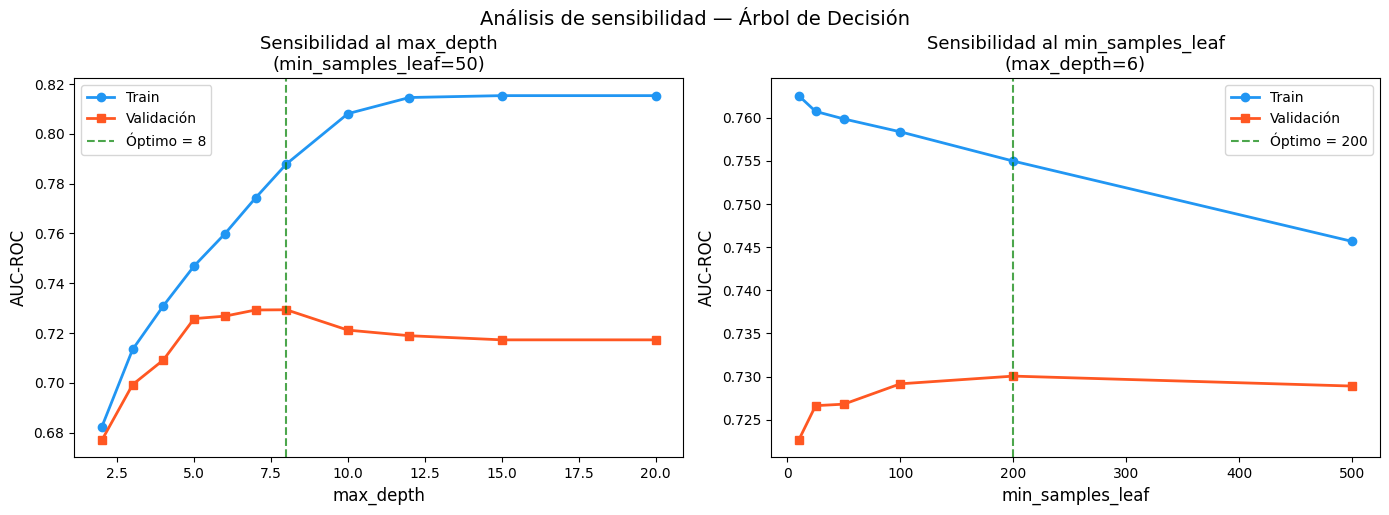


 max_depth óptimo (exploratorio)    : 8
 min_samples_leaf óptimo (exploratorio): 200


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: max_depth
axes[0].plot(depths, aucs_train_d, 'o-', color='#2196F3', label='Train', lw=2)
axes[0].plot(depths, aucs_val_d,   's-', color='#FF5722', label='Validación', lw=2)
axes[0].axvline(x=depths[np.argmax(aucs_val_d)], color='green',
                linestyle='--', alpha=0.7, label=f'Óptimo = {depths[np.argmax(aucs_val_d)]}')
axes[0].set_xlabel('max_depth', fontsize=12)
axes[0].set_ylabel('AUC-ROC', fontsize=12)
axes[0].set_title('Sensibilidad al max_depth\n(min_samples_leaf=50)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(False)

# Gráfico 2: min_samples_leaf
axes[1].plot(min_leaves, aucs_train_l, 'o-', color='#2196F3', label='Train', lw=2)
axes[1].plot(min_leaves, aucs_val_l,   's-', color='#FF5722', label='Validación', lw=2)
axes[1].axvline(x=min_leaves[np.argmax(aucs_val_l)], color='green',
                linestyle='--', alpha=0.7,
                label=f'Óptimo = {min_leaves[np.argmax(aucs_val_l)]}')
axes[1].set_xlabel('min_samples_leaf', fontsize=12)
axes[1].set_ylabel('AUC-ROC', fontsize=12)
axes[1].set_title('Sensibilidad al min_samples_leaf\n(max_depth=6)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(False)

plt.tight_layout()
plt.suptitle('Análisis de sensibilidad — Árbol de Decisión', fontsize=14, y=1.02)
plt.savefig('../../figuras/s11/sensibilidad_dt.png', bbox_inches='tight', dpi=150)
plt.show()

best_depth = depths[np.argmax(aucs_val_d)]
best_leaf  = min_leaves[np.argmax(aucs_val_l)]
print(f"\n max_depth óptimo (exploratorio)    : {best_depth}")
print(f" min_samples_leaf óptimo (exploratorio): {best_leaf}")

In [14]:
# ── Árbol de Decisión Final ───────────────────────────────────────────────────
dt_final = DecisionTreeClassifier(
    max_depth        = best_depth,
    min_samples_leaf = best_leaf,
    class_weight     = 'balanced',
    ccp_alpha        =  0.001,
    criterion        = 'entropy',
    random_state     = 42
)
dt_final.fit(X_train, y_train)

auc_dt_train = roc_auc_score(y_train, dt_final.predict_proba(X_train)[:,1])
auc_dt_test  = roc_auc_score(y_test,  dt_final.predict_proba(X_test)[:,1])
auc_dt_val   = roc_auc_score(y_val,   dt_final.predict_proba(X_val)[:,1])

print("=" * 55)
print(f'{"Decision Tree Mejorado":^55}')
print("=" * 55)
print(f"  Parámetros:")
print(f"    max_depth        : {dt_final.max_depth}")
print(f"    min_samples_leaf : {dt_final.min_samples_leaf}")
print(f"    ccp_alpha        : {dt_final.ccp_alpha:.6f}")
print(f"  Estructura:")
print(f"    Profundidad real : {dt_final.get_depth()}")
print(f"    Número de hojas  : {dt_final.get_n_leaves()}")
print(f"  Performance:")
print(f"    AUC – Train      : {auc_dt_train:.4f}")
print(f"    AUC – Test       : {auc_dt_test:.4f}")
print(f"    AUC – Validación : {auc_dt_val:.4f}")
print(f"    Brecha T–V       : {auc_dt_train - auc_dt_val:.4f}  ← reducida vs overfitting")
print("=" * 55)

                Decision Tree Mejorado                 
  Parámetros:
    max_depth        : 8
    min_samples_leaf : 200
    ccp_alpha        : 0.001000
  Estructura:
    Profundidad real : 8
    Número de hojas  : 26
  Performance:
    AUC – Train      : 0.7506
    AUC – Test       : 0.7349
    AUC – Validación : 0.7258
    Brecha T–V       : 0.0248  ← reducida vs overfitting


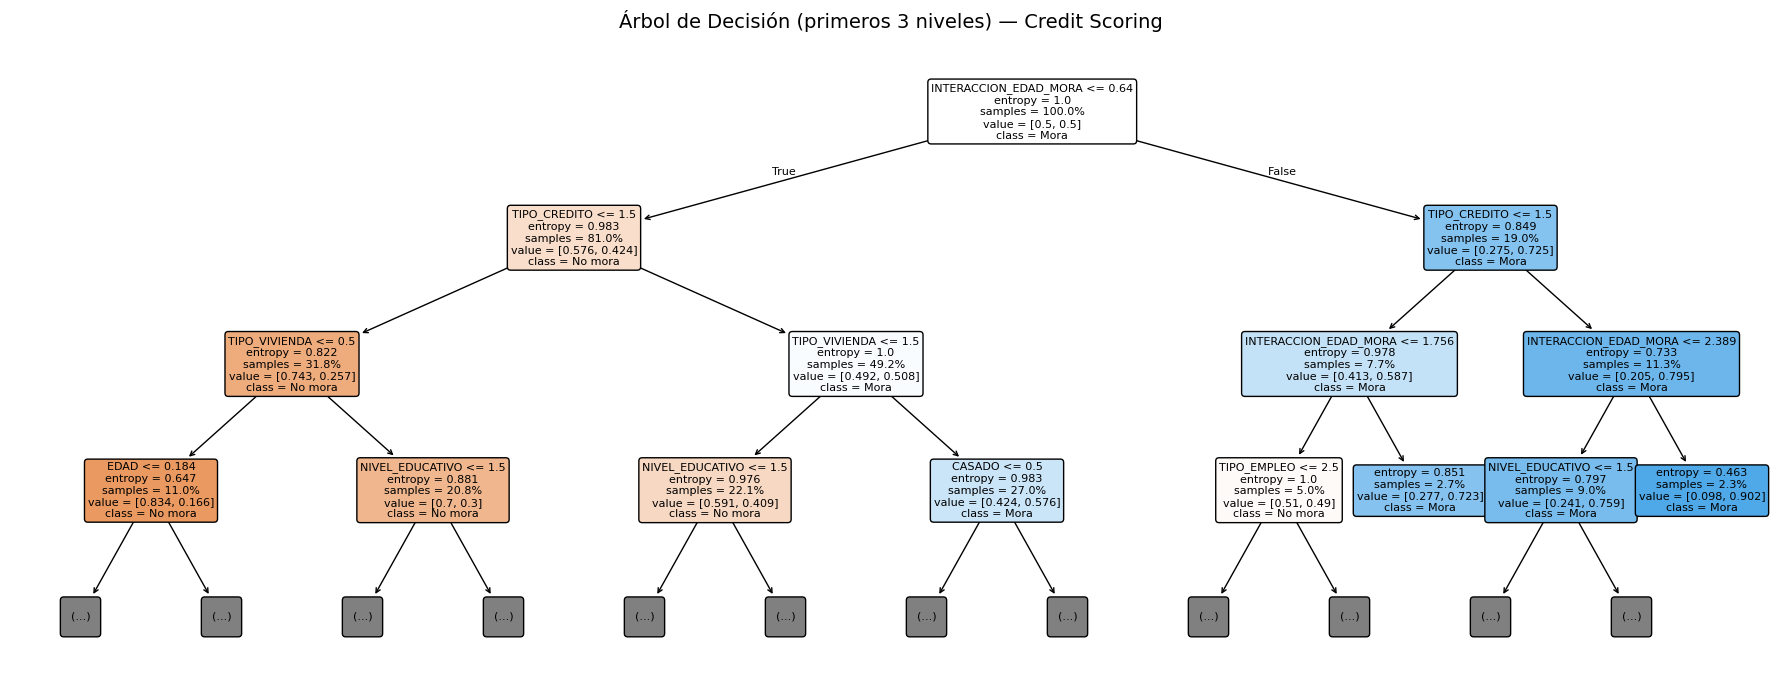


 Lectura del árbol:
   - 'value' = [proporción clase 0, proporción clase 1]
   - 'gini'  = impureza del nodo (0=puro, 0.5=máximo desorden)
   - 'samples' = fracción de observaciones que llegan a este nodo
   - Color azul oscuro → probabilidad alta de mora (clase 1)


In [15]:
# ── Visualización del árbol podado ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt_final,
    max_depth     = 3,
    feature_names = X_train.columns.tolist(),
    class_names   = ['No mora', 'Mora'],
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = ax,
    impurity      = True,
    proportion    = True
)
ax.set_title('Árbol de Decisión (primeros 3 niveles) — Credit Scoring', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../../figuras/s11/arbol_visualizacion.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n Lectura del árbol:")
print("   - 'value' = [proporción clase 0, proporción clase 1]")
print("   - 'gini'  = impureza del nodo (0=puro, 0.5=máximo desorden)")
print("   - 'samples' = fracción de observaciones que llegan a este nodo")
print("   - Color azul oscuro → probabilidad alta de mora (clase 1)")

# 🌳 **3· Random Forest**

## **3.1 El problema del árbol individual: alta varianza**

Un árbol de decisión tiene **alta varianza**: si cambiamos ligeramente el dataset de entrenamiento, el árbol resultante puede ser muy diferente. Esto lo hace **inestable** como modelo de scoring crediticio.
La solución: **construir muchos árboles y promediar sus predicciones**.

## **3.2 Bagging: Bootstrap Aggregating**

**Paso 1 — Bootstrapping:** De $n$ clientes en entrenamiento, tomamos $n$ muestras **con reemplazo**. Cada muestra:
- Contiene ~63% de los clientes originales únicos.
- El 37% restante no se usa → se llama muestra **Out-of-Bag (OOB)**.

**Paso 2 — Entrenar un árbol** sobre cada muestra bootstrap.

**Paso 3 — Agregar:** Para clasificación, promediamos las probabilidades de todos los árboles:

$$\hat{p}(x) = \frac{1}{B} \sum_{b=1}^{B} p_b(x)$$

## **3.3 Aleatoriedad en features: el ingrediente secreto**

Random Forest va un paso más allá del bagging puro: en **cada split**, solo considera un subconjunto aleatorio de $m$ variables (en lugar de todas las $p$).

¿Por qué? Para **descorrelacionar** los árboles. Si todos los árboles usan las mismas variables en los mismos splits, sus predicciones serán muy similares y el promedio no ganará mucho. Con aleatoriedad en features:
- Los árboles son más diversos.
- Sus errores se cancelan al promediar.
- El ensemble es más robusto que cualquier árbol individual.

El valor estándar es $m = \sqrt{p}$ para clasificación (regla empírica de Breiman).

In [16]:
params_rf = pd.DataFrame({
    'Parámetro': [
        'n_estimators',
        'max_depth',
        'min_samples_leaf',
        'max_features',
        'class_weight',
        'n_jobs',
        'bootstrap'
    ],
    'Qué controla': [
        'Número de árboles en el bosque',
        'Profundidad máxima de cada árbol individual',
        'Mínimo de obs. en cada hoja final',
        'Nº de variables aleatorias en cada split',
        'Peso de las clases (ajuste por desbalance)',
        'Uso de procesadores (paralelismo)',
        'Muestreo con reemplazo (Bagging)'
    ],
    'Valor bajo → ': [
        'Poca estabilidad, predicciones ruidosas',
        'Árboles débiles (underfitting)',
        'Hojas pequeñas (riesgo de overfit individual)',
        'Árboles muy distintos entre sí (diversidad)',
        'Ignora el desbalance de la mora',
        'Lento (usa un solo núcleo)',
        'Usa toda la data (no hay validación OOB)'
    ],
    'Valor alto → ': [
        'Convergencia y estabilidad (no hace overfit)',
        'Árboles complejos (overfitting individual)',
        'Hojas más robustas (mejor generalización)',
        'Árboles más parecidos entre sí',
        'Prioriza detectar a los clientes morosos',
        'Más rápido (usa todos los núcleos)',
        'Entrena con muestras distintas (estándar)'
    ],
    'Rango recomendado (scoring)': [
        '100 – 1000',
        '5 – 12 (en RF puede ser un poco mayor)',
        '50 – 500 (igual que en Decision Tree)',
        "'sqrt' (raíz cuadrada del total de vars)",
        "'balanced' o 'balanced_subsample'",
        '-1 (para usar toda tu PC)',
        'True (siempre activo)'
    ]
})

with pd.option_context('display.max_colwidth', 60):
    display(params_rf)

,Parámetro,Qué controla,Valor bajo →,Valor alto →,Rango recomendado (scoring)
0,n_estimators,Número de árboles en el bosque,"Poca estabilidad, predicciones ruidosas",Convergencia y estabilidad (no hace overfit),100 – 1000
1,max_depth,Profundidad máxima de cada árbol individual,Árboles débiles (underfitting),Árboles complejos (overfitting individual),5 – 12 (en RF puede ser un poco mayor)
2,min_samples_leaf,Mínimo de obs. en cada hoja final,Hojas pequeñas (riesgo de overfit individual),Hojas más robustas (mejor generalización),50 – 500 (igual que en Decision Tree)
3,max_features,Nº de variables aleatorias en cada split,Árboles muy distintos entre sí (diversidad),Árboles más parecidos entre sí,'sqrt' (raíz cuadrada del total de vars)
4,class_weight,Peso de las clases (ajuste por desbalance),Ignora el desbalance de la mora,Prioriza detectar a los clientes morosos,'balanced' o 'balanced_subsample'
5,n_jobs,Uso de procesadores (paralelismo),Lento (usa un solo núcleo),Más rápido (usa todos los núcleos),-1 (para usar toda tu PC)
6,bootstrap,Muestreo con reemplazo (Bagging),Usa toda la data (no hay validación OOB),Entrena con muestras distintas (estándar),True (siempre activo)


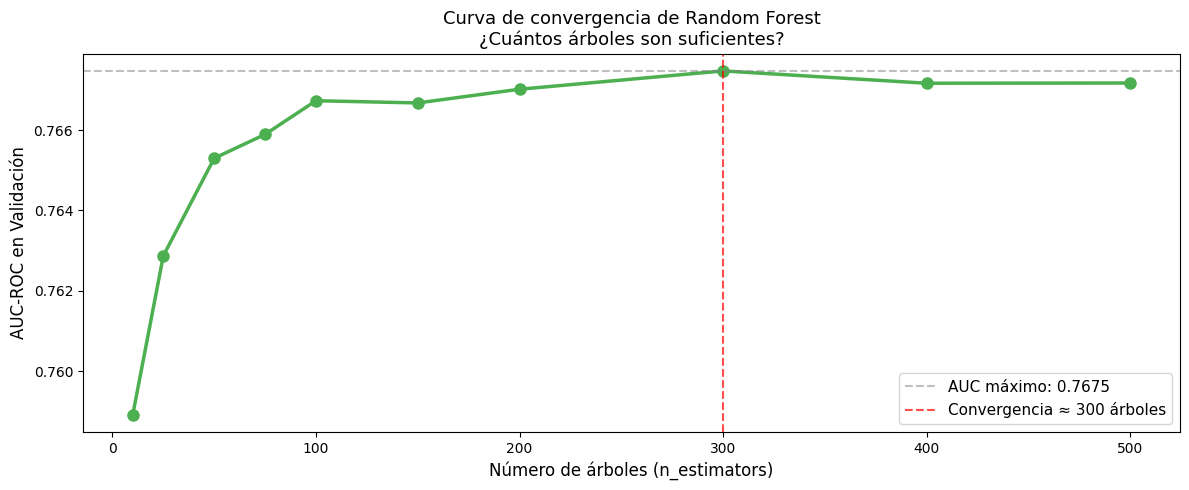


📌 El AUC se estabiliza alrededor de 300 árboles.
   Usar más árboles no mejora el performance pero sí el tiempo de cómputo.
   A más árboles el modelo es más robusto y menos propenso a errores por datos atípicos. No causa overfitting.


In [17]:
n_trees_list = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
aucs_ntrees  = []

for n in n_trees_list:
    rf_temp = RandomForestClassifier(
        n_estimators     = n,
        max_depth        = 8,
        min_samples_leaf = 50,
        max_features     = 'sqrt',
        class_weight     = 'balanced',
        random_state     = 42,
        n_jobs           = -1
    )
    rf_temp.fit(X_train, y_train)
    aucs_ntrees.append(roc_auc_score(y_val, rf_temp.predict_proba(X_val)[:,1]))

plt.figure(figsize=(12, 5))
plt.plot(n_trees_list, aucs_ntrees, 'o-', color='#4CAF50', lw=2.5, ms=8)
plt.axhline(max(aucs_ntrees), color='gray', linestyle='--', alpha=0.5,
            label=f'AUC máximo: {max(aucs_ntrees):.4f}')

convergencia_idx = [i for i, v in enumerate(aucs_ntrees) if v >= max(aucs_ntrees)][0]
plt.axvline(n_trees_list[convergencia_idx], color='red', linestyle='--', alpha=0.7,
            label=f'Convergencia ≈ {n_trees_list[convergencia_idx]} árboles')

plt.xlabel('Número de árboles (n_estimators)', fontsize=12)
plt.ylabel('AUC-ROC en Validación', fontsize=12)
plt.title('Curva de convergencia de Random Forest\n¿Cuántos árboles son suficientes?', fontsize=13)
plt.legend(fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig('../../figuras/s11/convergencia_rf.png', bbox_inches='tight', dpi=150)
plt.show()

n_optimo = n_trees_list[convergencia_idx]
print(f"\n📌 El AUC se estabiliza alrededor de {n_optimo} árboles.")
print("   Usar más árboles no mejora el performance pero sí el tiempo de cómputo.")
print("   A más árboles el modelo es más robusto y menos propenso a errores por datos atípicos. No causa overfitting.")

## **3.6 Out-of-Bag (OOB): validación gratuita**

Cada árbol solo ve ~63% de los datos de entrenamiento. El 37% restante (**OOB**) se usa como set de validación interno. El `oob_score_` es una estimación honesta del AUC **sin necesidad de usar el set de validación**.

Esto es muy útil para:
1. Monitorear el modelo durante el entrenamiento.
2. Tener una estimación de generalización cuando los datos son escasos.
3. Detectar overfitting antes de evaluar en el set de validación.

In [18]:
# ── Random Forest con OOB score activado ─────────────────────────────────────
rf_base = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 10,
    min_samples_leaf = 50,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    bootstrap        = True,
    oob_score        = True,      # ← activa el OOB
    random_state     = 42,
    n_jobs           = -1
)
rf_base.fit(X_train, y_train)

# El oob_score usa accuracy por default; calculamos AUC manualmente con oob_decision_function_
auc_oob = roc_auc_score(y_train, rf_base.oob_decision_function_[:, 1])
auc_rf_train = roc_auc_score(y_train, rf_base.predict_proba(X_train)[:,1])
auc_rf_val   = roc_auc_score(y_val,   rf_base.predict_proba(X_val)[:,1])

print("=" * 55)
print("Random Forest (sin optimizar)")
print("=" * 55)
print(f"  AUC – Train (in-bag)  : {auc_rf_train:.4f}  ← sesgado al alza")
print(f"  AUC – OOB             : {auc_oob:.4f}  ← estimado honesto")
print(f"  AUC – Validación      : {auc_rf_val:.4f}  ← referencia real")
print(f"  Brecha OOB–Val        : {abs(auc_oob - auc_rf_val):.4f}  ← idealmente pequeña")
print("=" * 55)
print("\n Si la brecha OOB–Val es pequeña, el OOB es un buen proxy.")

Random Forest (sin optimizar)
  AUC – Train (in-bag)  : 0.8162  ← sesgado al alza
  AUC – OOB             : 0.7633  ← estimado honesto
  AUC – Validación      : 0.7682  ← referencia real
  Brecha OOB–Val        : 0.0049  ← idealmente pequeña

 Si la brecha OOB–Val es pequeña, el OOB es un buen proxy.


In [19]:
# ── Random Forest Final ───────────────────────────────────────────────────
auc_rf_train = roc_auc_score(y_train, rf_base.predict_proba(X_train)[:,1])
auc_rf_test  = roc_auc_score(y_test,  rf_base.predict_proba(X_test)[:,1])
auc_rf_val   = roc_auc_score(y_val,   rf_base.predict_proba(X_val)[:,1])

# Cálculos estructurales promedios (RF es una lista de árboles)
avg_depth  = sum([tree.get_depth() for tree in rf_base.estimators_]) / len(rf_base.estimators_)
avg_leaves = sum([tree.get_n_leaves() for tree in rf_base.estimators_]) / len(rf_base.estimators_)

print("=" * 55)
print(f"{'Random Forest Mejorado':^55}")
print("=" * 55)
print(f"  Configuración:")
print(f"    n_estimators      : {rf_base.n_estimators}")
print(f"    max_depth (lim)   : {rf_base.max_depth}")
print(f"    min_samples_leaf  : {rf_base.min_samples_leaf}")
print(f"    max_features      : {rf_base.max_features}")
print(f"  Estructura Promedio:")
print(f"    Profundidad real  : {avg_depth:.1f}")
print(f"    Número de hojas   : {avg_leaves:.1f}")
print(f"  Performance (AUC):")
print(f"    Train             : {auc_rf_train:.4f}")
print(f"    Test              : {auc_rf_test:.4f}")
print(f"    Validación        : {auc_rf_val:.4f}")
print(f"    Brecha T–V        : {auc_rf_train - auc_rf_val:.4f}") 
print("=" * 55)

                Random Forest Mejorado                 
  Configuración:
    n_estimators      : 300
    max_depth (lim)   : 10
    min_samples_leaf  : 50
    max_features      : sqrt
  Estructura Promedio:
    Profundidad real  : 10.0
    Número de hojas   : 141.3
  Performance (AUC):
    Train             : 0.8162
    Test              : 0.7686
    Validación        : 0.7682
    Brecha T–V        : 0.0480



# 🔧 **4· Optimización de hiperparámetros y Validación Cruzada**

## **4.1 ¿Por qué Validación Cruzada Estratificada?**
En credit scoring tenemos **clases desbalanceadas** (típicamente 5–20% de incumplimiento). Si hacemos un split aleatorio del train para validar, un fold podría tener 3% de mora y otro 25% haciendo que las métricas sean ruidosas e inconsistentes.

**`StratifiedKFold`** garantiza que cada fold tiene aproximadamente la misma proporción de morosos que el dataset original.

<div style="background-color: white; display: inline-block; padding: 8px; border-radius: 4px;">
    <img src="../../figuras/s11/KFold.png" width="500"/>
    <img src="../../figuras/s11/StratifiedKFold.png" width="500"/>
</div>


## **4.2 ¿GridSearch o RandomizedSearch?**

| Método | Qué hace | Cuándo usarlo |
|--------|----------|---------------|
| `GridSearchCV` | Prueba **todas** las combinaciones del grid | Grid pequeño (<200 combinaciones) |
| `RandomizedSearchCV` | Muestrea **aleatoriamente** N combinaciones | Grid grande; búsqueda exploratoria |

Para Random Forest con 4-5 hiperparámetros, el espacio puede tener miles de combinaciones. `RandomizedSearchCV` con 50-100 iteraciones suele encontrar una solución casi tan buena como el grid completo.

<img src="../../figuras/s11/gridsearch_randomsearch.png" width="800"/>


## **4.3 Métrica de optimización: AUC-ROC**
Usamos `scoring='roc_auc'` porque en credit scoring queremos maximizar la capacidad de discriminar buenos de malos pagadores, independientemente del umbral de corte que luego se defina según el apetito de riesgo del negocio.

In [20]:
# ── RandomizedSearchCV para Árbol de Decisión ────────────────────────────────
param_dist_dt = {
    'max_depth'        : [3, 5, 8, 10],
    'min_samples_leaf' : sp_randint(20, 300), # distribución uniforme entre 20-300
    'min_samples_split': sp_randint(40, 600), # distribución uniforme entre 40-600
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : ['balanced', None],
    'ccp_alpha'        : [0.0, 0.0001, 0.001, 0.005]
}

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs_dt = RandomizedSearchCV(
    estimator           = DecisionTreeClassifier(random_state=42),
    param_distributions = param_dist_dt,
    n_iter              = 50,          # combinación aleatoria
    cv                  = cv_strat,
    scoring             = 'roc_auc',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    return_train_score  = True
)

print("Buscando mejores hiperparámetros para Decision Tree")
rs_dt.fit(X_train, y_train)

print(f"\n Mejores hiperparámetros (DT):")
for k, v in rs_dt.best_params_.items():
    print(f"   {k:<25}: {v}")
print(f"\n   AUC CV (media 3 folds): {rs_dt.best_score_:.4f}")

Buscando mejores hiperparámetros para Decision Tree
Fitting 3 folds for each of 50 candidates, totalling 150 fits

 Mejores hiperparámetros (DT):
   ccp_alpha                : 0.0001
   class_weight             : balanced
   criterion                : entropy
   max_depth                : 10
   min_samples_leaf         : 211
   min_samples_split        : 316

   AUC CV (media 3 folds): 0.7324


In [21]:
# ── RandomizedSearchCV para Random Forest ────────────────────────────────────
param_dist_rf = {
    'n_estimators'     : [200, 300, 400, 500],
    'max_depth'        : [6, 8, 10, 12, None],
    'min_samples_leaf' : sp_randint(30, 250),
    'min_samples_split': sp_randint(60, 500),
    'max_features'     : ['sqrt', 'log2', 0.2, 0.3],
    'class_weight'     : ['balanced', None],
    'max_samples'      : [0.7, 0.8, 0.9, 1.0]
}

rs_rf = RandomizedSearchCV(
    estimator           = RandomForestClassifier(
                            bootstrap=True, oob_score=True,
                            random_state=42, n_jobs=-1),
    param_distributions = param_dist_rf,
    n_iter              = 50,
    cv                  = cv_strat,
    scoring             = 'roc_auc',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    return_train_score  = True
)

print("Buscando mejores hiperparámetros para Random Forest")
rs_rf.fit(X_train, y_train)

print(f"\n Mejores hiperparámetros (RF):")
for k, v in rs_rf.best_params_.items():
    print(f"   {k:<25}: {v}")
print(f"\n   AUC CV (media 3 folds): {rs_rf.best_score_:.4f}")

Buscando mejores hiperparámetros para Random Forest
Fitting 3 folds for each of 50 candidates, totalling 150 fits

 Mejores hiperparámetros (RF):
   class_weight             : balanced
   max_depth                : None
   max_features             : 0.2
   max_samples              : 0.9
   min_samples_leaf         : 58
   min_samples_split        : 95
   n_estimators             : 200

   AUC CV (media 3 folds): 0.7612


In [22]:
dt_opt = rs_dt.best_estimator_
rf_opt = rs_rf.best_estimator_

# Reentrenar en train completo con los mejores parámetros
dt_opt.fit(X_train, y_train)
rf_opt.fit(X_train, y_train)

print("Modelos optimizados entrenados en el dataset completo de train.")
print(f"   DT óptimo — profundidad: {dt_opt.get_depth()}, hojas: {dt_opt.get_n_leaves()}")
print(f"   RF óptimo — árboles: {rf_opt.n_estimators}, profundidad: {rf_opt.max_depth}")

Modelos optimizados entrenados en el dataset completo de train.
   DT óptimo — profundidad: 9, hojas: 59
   RF óptimo — árboles: 200, profundidad: None


In [30]:
model_path

'c:\\Users\\einfantesz\\Documents\\CreditScoring\\CreditScoring\\modelos\\s11'

In [32]:
joblib.dump(dt_opt, os.path.join(model_path, 'modelo_dt_optimizado.pkl'))
joblib.dump(rf_opt, os.path.join(model_path, 'modelo_rf_optimizado.pkl'))

['c:\\Users\\einfantesz\\Documents\\CreditScoring\\CreditScoring\\models\\s11\\modelo_rf_optimizado.pkl']

# 📊 **5. Evaluación de Modelos**

1. Matriz de Confusión | Curva AUC-ROC | Precision - Recall
2. Evolución del Gini
3. Distribución de las Probabilidades según clase


── Test Set Metrics (OOT)  —  threshold = 0.4856 ────────
  ROC AUC          : 0.7352
  PR AUC           : 0.4539
  Recall           : 0.6888
  Precision        : 0.3679
  F1 Score         : 0.4797

              precision    recall  f1-score   support

    Good (0)       0.88      0.65      0.75      6095
     Bad (1)       0.37      0.69      0.48      1780

    accuracy                           0.66      7875
   macro avg       0.62      0.67      0.61      7875
weighted avg       0.76      0.66      0.69      7875



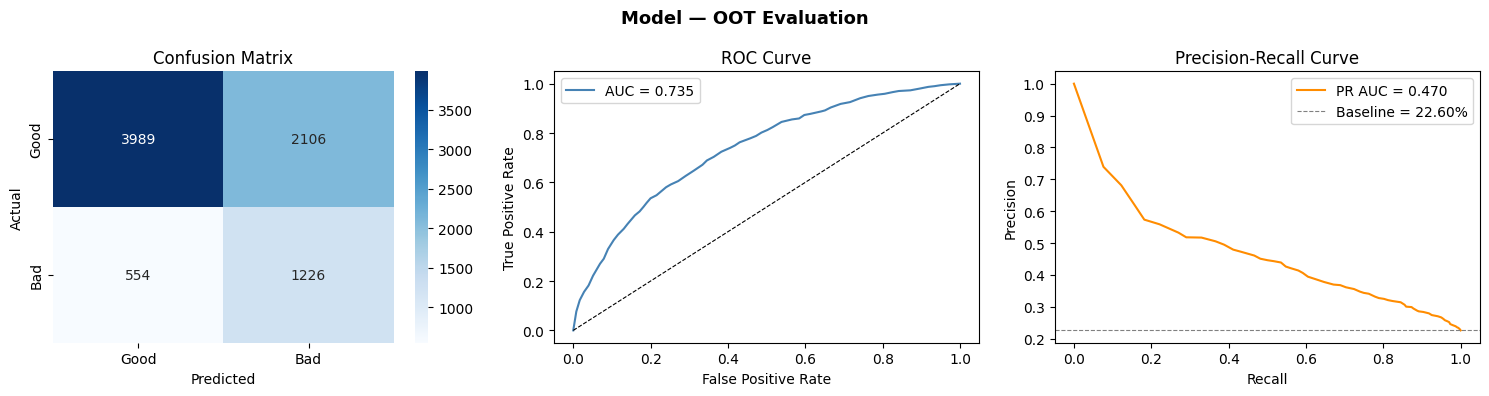

[plot]  Saved → '../../figuras/s11/evaluation.png'


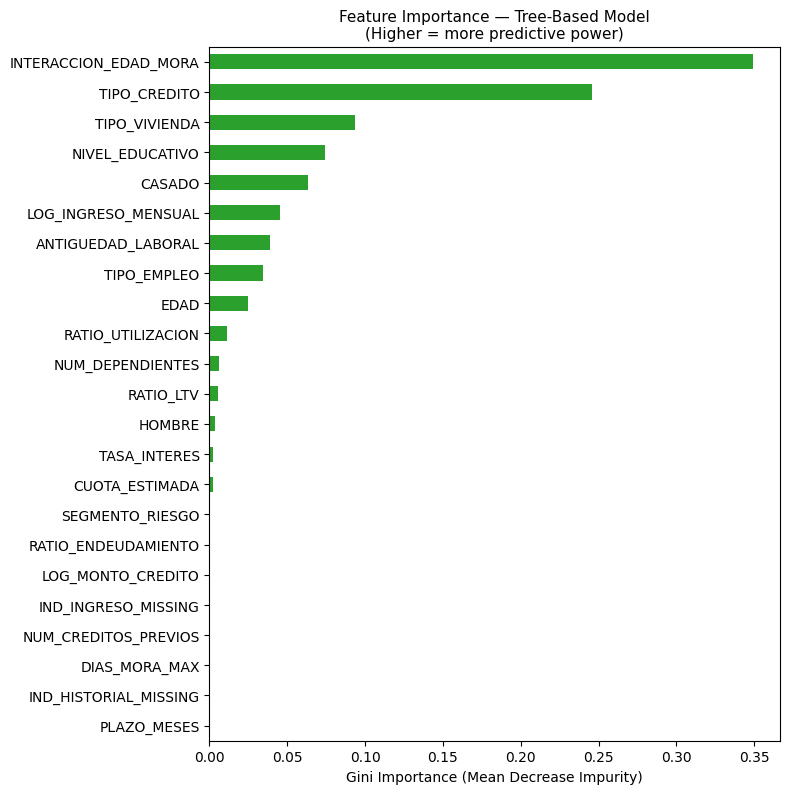

[plot]  Saved → '../../figuras/s11/feature_importance.png'

✅  Evaluation completed.

── Test Set Metrics (OOT)  —  threshold = 0.4856 ────────
  ROC AUC          : 0.7304
  PR AUC           : 0.4492
  Recall           : 0.6673
  Precision        : 0.3676
  F1 Score         : 0.4741

              precision    recall  f1-score   support

    Good (0)       0.87      0.67      0.76      3708
     Bad (1)       0.37      0.67      0.47      1076

    accuracy                           0.67      4784
   macro avg       0.62      0.67      0.62      4784
weighted avg       0.76      0.67      0.69      4784



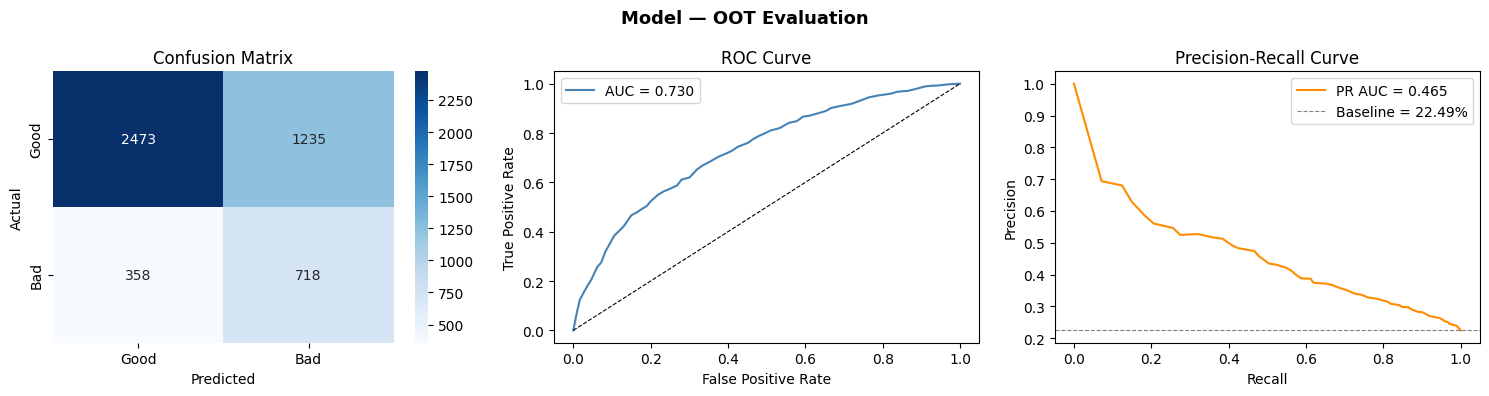

[plot]  Saved → '../../figuras/s11/evaluation.png'


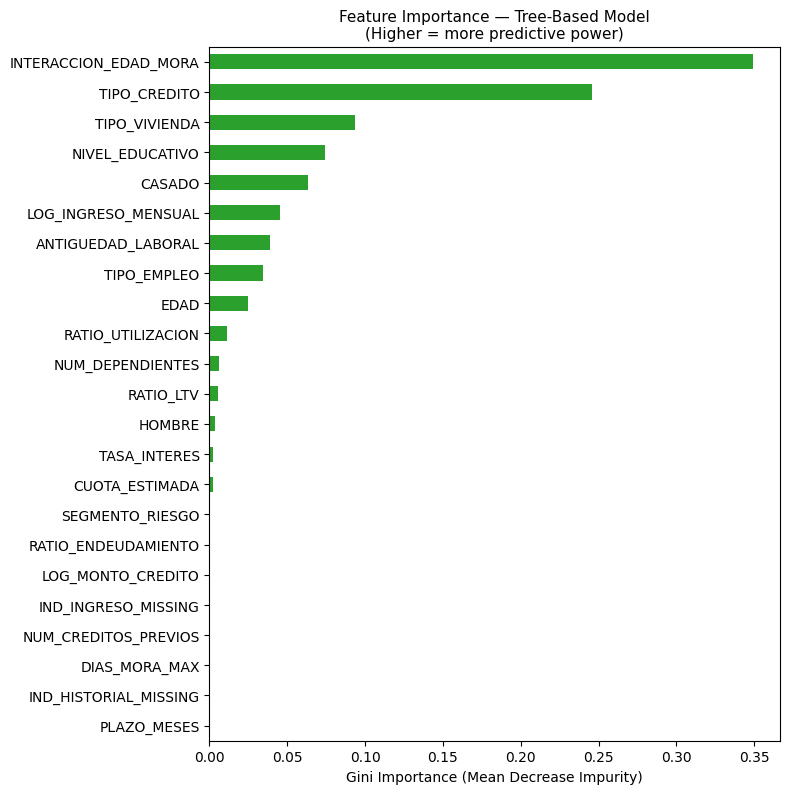

[plot]  Saved → '../../figuras/s11/feature_importance.png'

✅  Evaluation completed.


In [23]:
features = X_train.columns.tolist() 

# Para Decision Tree
eval_dt_test = Evaluation(
    model=dt_opt,
    x=X_test,
    y=y_test,
    features=features
)
eval_dt_test.run_all()

# Para Random Forest
eval_dt_val = Evaluation(
    model=dt_opt,
    x=X_val,
    y=y_val,
    features=features
)

eval_dt_val.run_all()


── Test Set Metrics (OOT)  —  threshold = 0.4670 ────────
  ROC AUC          : 0.7676
  PR AUC           : 0.5150
  Recall           : 0.7163
  Precision        : 0.3972
  F1 Score         : 0.5110

              precision    recall  f1-score   support

    Good (0)       0.89      0.68      0.77      6095
     Bad (1)       0.40      0.72      0.51      1780

    accuracy                           0.69      7875
   macro avg       0.64      0.70      0.64      7875
weighted avg       0.78      0.69      0.71      7875



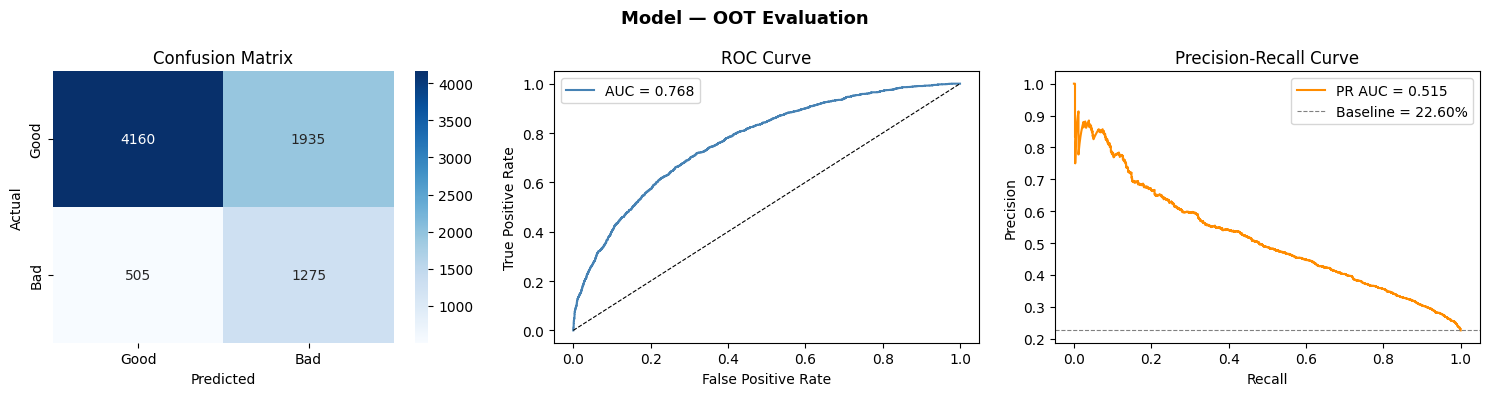

[plot]  Saved → '../../figuras/s11/evaluation.png'


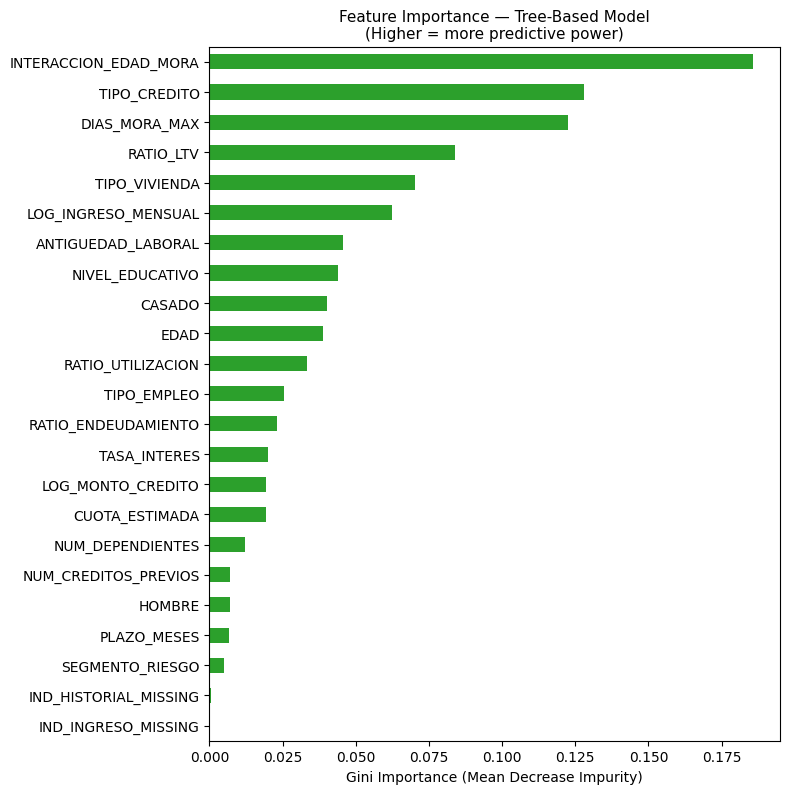

[plot]  Saved → '../../figuras/s11/feature_importance.png'

✅  Evaluation completed.

── Test Set Metrics (OOT)  —  threshold = 0.4994 ────────
  ROC AUC          : 0.7669
  PR AUC           : 0.5128
  Recall           : 0.6608
  Precision        : 0.4335
  F1 Score         : 0.5236

              precision    recall  f1-score   support

    Good (0)       0.88      0.75      0.81      3708
     Bad (1)       0.43      0.66      0.52      1076

    accuracy                           0.73      4784
   macro avg       0.66      0.71      0.67      4784
weighted avg       0.78      0.73      0.75      4784



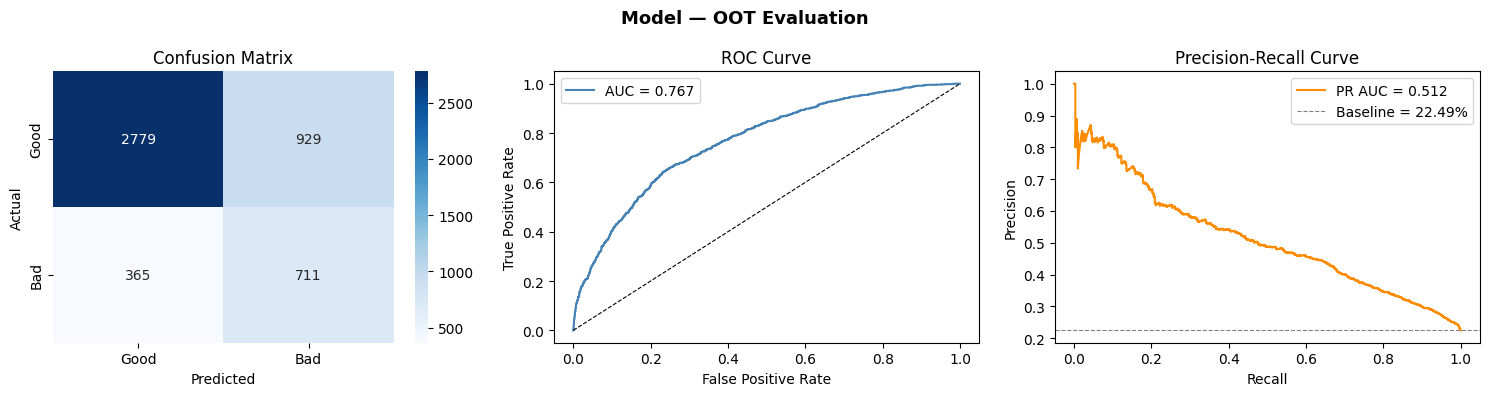

[plot]  Saved → '../../figuras/s11/evaluation.png'


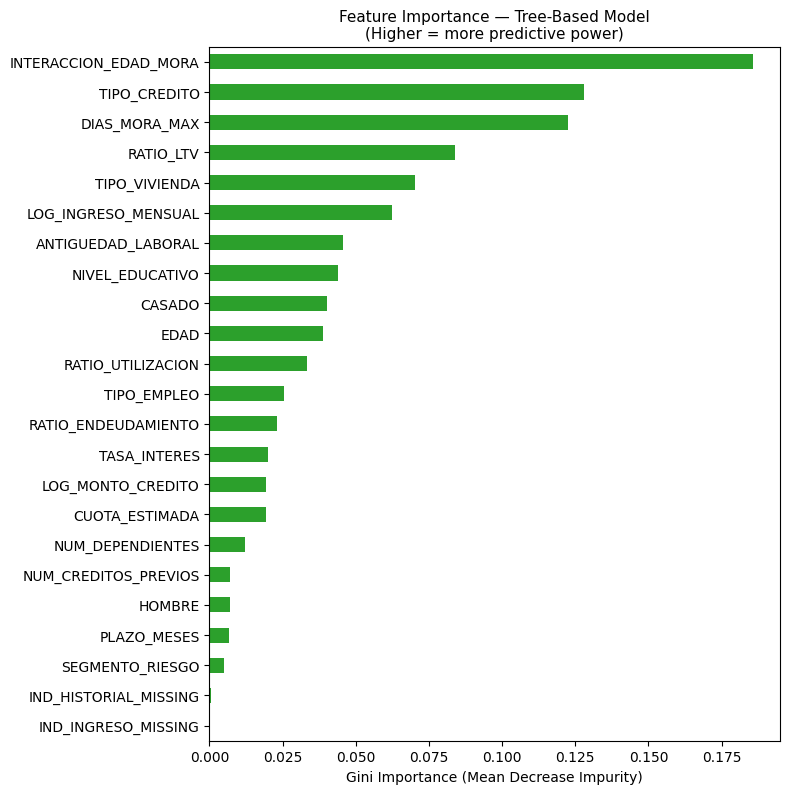

[plot]  Saved → '../../figuras/s11/feature_importance.png'

✅  Evaluation completed.


In [24]:
# Para Random Forest
eval_rf_test = Evaluation(
    model=rf_opt,
    x=X_test,
    y=y_test,
    features=features
)
eval_rf_test.run_all()

eval_rf_val = Evaluation(
    model=rf_opt,
    x=X_val,
    y=y_val,
    features=features
)
eval_rf_val.run_all()

In [25]:
train = X_train.copy()
train['target'] = y_train.values 
train['prob_target'] = rf_opt.predict_proba(X_train)[:, 1]

val = X_val.copy()
val['target'] = y_val.values
val['prob_target'] = rf_opt.predict_proba(X_val)[:, 1]

test = X_test.copy()
test['target'] = y_test.values
test['prob_target'] = rf_opt.predict_proba(X_test)[:, 1]

In [26]:
gini_records = []
for label, df in [('Train', train), ('Val', val), ('OOT Test', test)]:
    for month, grp in df.groupby(level='MES_STR'):
        auc_val  = roc_auc_score(grp['target'], grp['prob_target'])
        fpr, tpr, _ = roc_curve(grp['target'], grp['prob_target'])
        gini_records.append({
            'month'   : month,
            'set'     : label,
            'Gini'    : round(2 * auc_val - 1, 4),
            'KS'      : round(float(np.max(tpr - fpr)), 4),
            'n'       : len(grp),
            'bad_rate': round(grp['target'].mean(), 4)
        })

gini_df = pd.DataFrame(gini_records).sort_values('month').reset_index(drop=True)
print(gini_df)

      month       set    Gini      KS     n  bad_rate
0   2025-01     Train  0.5726  0.4505  1216    0.2146
1   2025-02     Train  0.6750  0.5258  1220    0.2148
2   2025-03     Train  0.6092  0.4546  1442    0.2240
3   2025-04     Train  0.6202  0.4860  1566    0.2261
4   2025-05     Train  0.6510  0.5039  1724    0.2303
5   2025-06     Train  0.6448  0.4946  1727    0.2195
6   2025-07     Train  0.6253  0.4848  1929    0.2322
7   2025-08     Train  0.6245  0.4942  2015    0.2159
8   2025-09     Train  0.6408  0.4919  2173    0.2296
9   2025-10     Train  0.5914  0.4430  2329    0.2246
10  2025-11       Val  0.5555  0.4212  2296    0.2282
11  2025-12       Val  0.5131  0.4084  2488    0.2219
12  2026-01  OOT Test  0.5359  0.4113  2583    0.2245
13  2026-02  OOT Test  0.5457  0.4134  2452    0.2300
14  2026-03  OOT Test  0.5258  0.3935  2840    0.2239


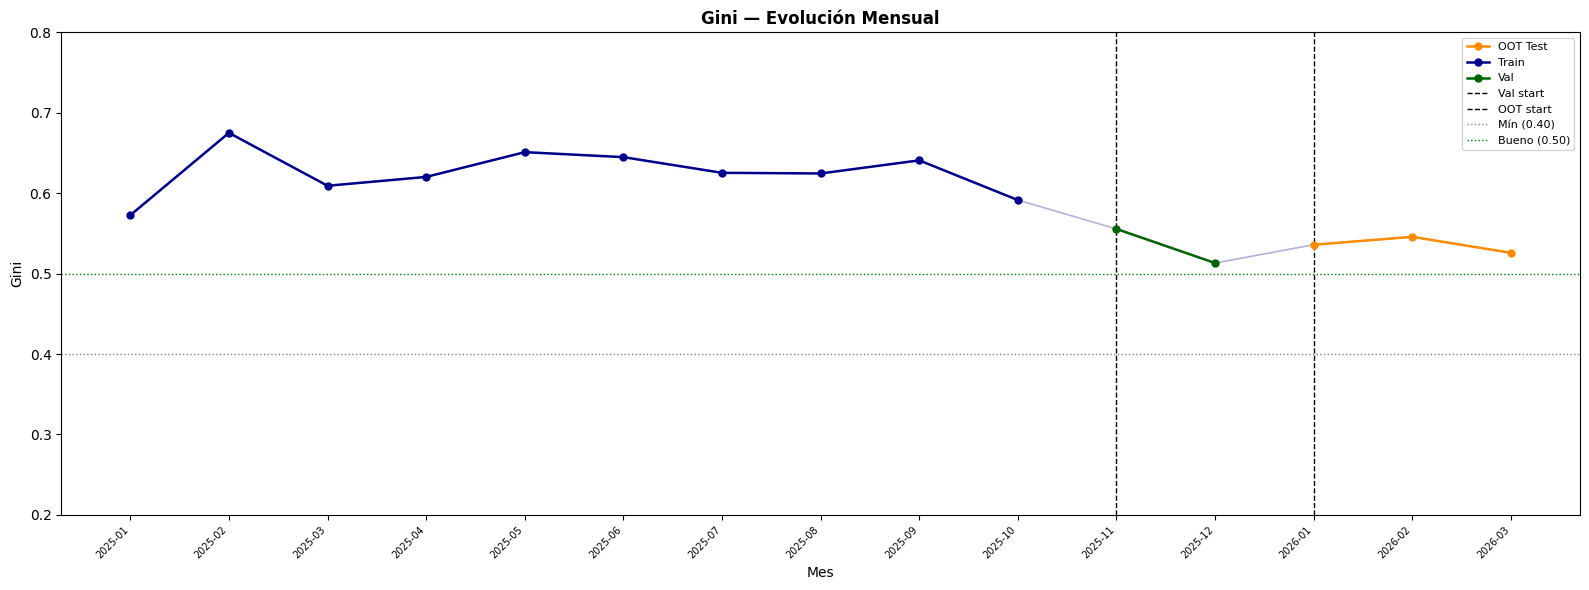

In [27]:
all_months = gini_df['month'].unique().tolist()
month_to_x = {m: i for i, m in enumerate(all_months)}

fig, ax = plt.subplots(figsize=(16, 6))
palette = {'Train': 'darkblue', 'Val': 'darkgreen', 'OOT Test': 'darkorange'}

# Línea continua uniendo train + val + OOT
ax.plot(gini_df['month'].map(month_to_x), gini_df['Gini'], color='darkblue', linewidth=1.2, alpha=0.3, zorder=1)

# Puntos por set con color
for label, grp in gini_df.groupby('set'):
    xs = grp['month'].map(month_to_x)
    ax.plot(xs, grp['Gini'], marker='o', markersize=5,
            linewidth=1.8, label=label, color=palette[label], zorder=3)
    
ax.axvline(month_to_x['2025-11'], color='black', linestyle='--', linewidth=1, label='Val start')
ax.axvline(month_to_x['2026-01'], color='black', linestyle='--', linewidth=1, label='OOT start')
ax.axhline(0.40, color='grey',  linestyle=':', linewidth=1, label='Mín (0.40)')
ax.axhline(0.50, color='green', linestyle=':', linewidth=1, label='Bueno (0.50)')

ax.set_xticks(range(len(all_months)))
ax.set_xticklabels(all_months, rotation=45, ha='right', fontsize=7)
ax.set_title('Gini — Evolución Mensual', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Gini')
ax.legend(fontsize=8)
ax.set_ylim(0.2, 0.8)
plt.tight_layout()
plt.show()

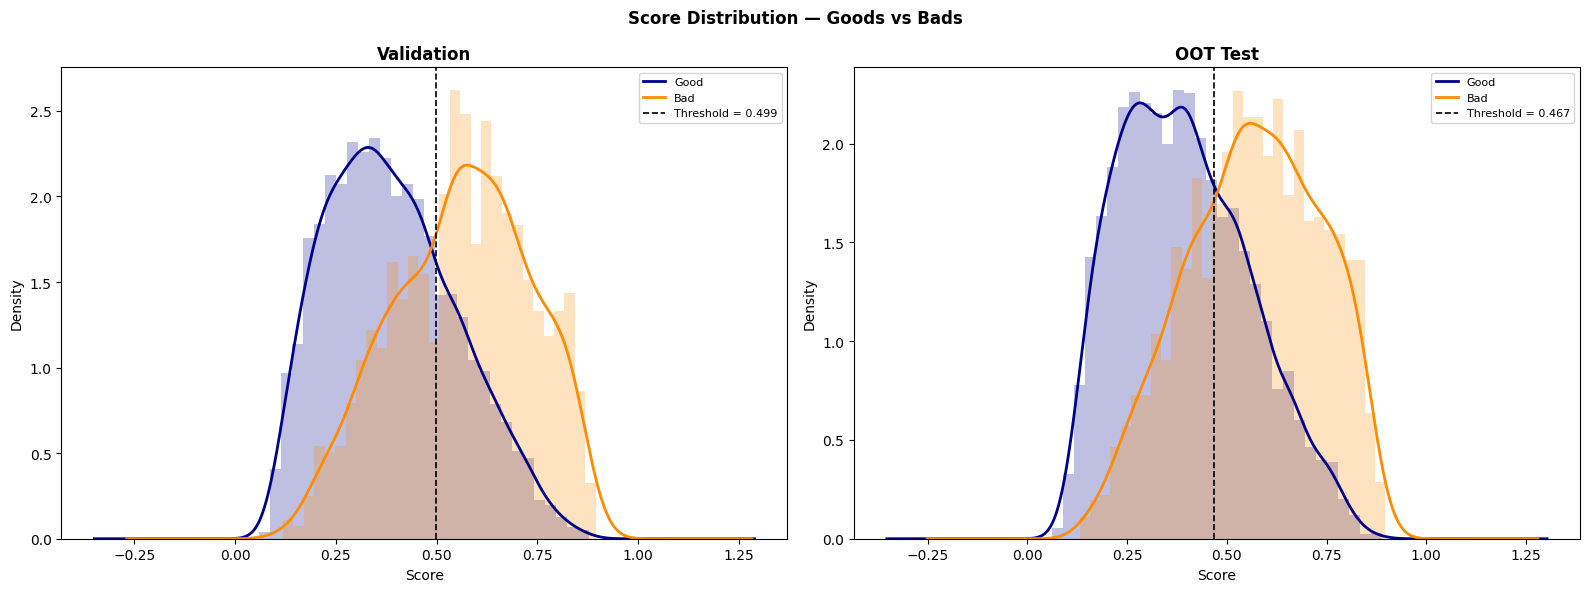

In [28]:
threshold_val = eval_rf_val.cut_off
threshold_test = eval_rf_test.cut_off

datasets = [
    ('Validation', val, threshold_val),
    ('OOT Test', test, threshold_test)
           ]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, df, threshold) in zip(axes, datasets):
    for cls, color, name in [(0, 'darkblue', 'Good'), (1, 'darkorange', 'Bad')]:
        subset = df[df['target'] == cls]['prob_target']
        
        # KDE
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=name)
        
        # Histograma
        ax.hist(subset, bins=30, alpha=0.25, color=color, density=True)
    
    # Línea de threshold específica
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1.2,
               label=f'Threshold = {threshold:.3f}')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

fig.suptitle('Score Distribution — Goods vs Bads', fontweight='bold')
plt.tight_layout()
plt.show()